In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('airline_tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df['text'].iloc[12]

"@VirginAmerica This is such a great deal! Already thinking about my 2nd trip to @Australia &amp; I haven't even gone on my 1st trip yet! ;p"

<Axes: xlabel='airline_sentiment', ylabel='count'>

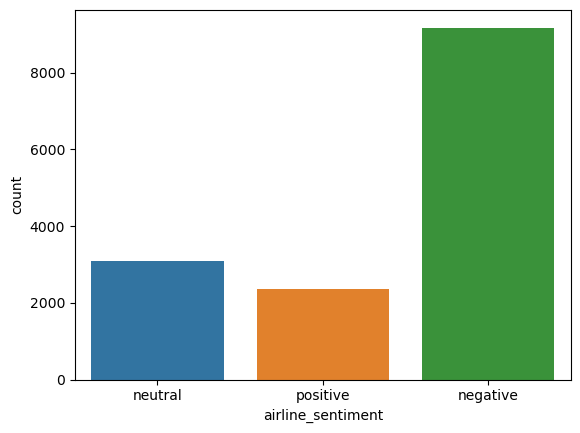

In [5]:
sns.countplot(data=df,x='airline_sentiment')

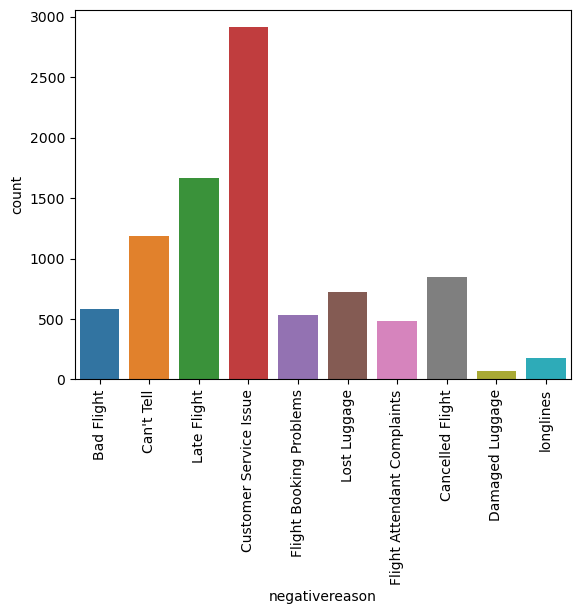

In [7]:
sns.countplot(data=df,x='negativereason')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='airline', ylabel='count'>

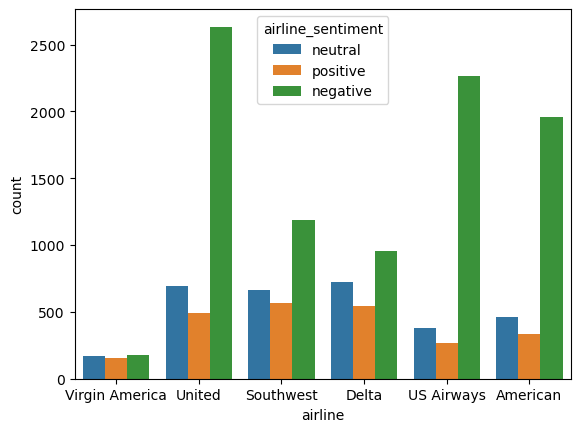

In [8]:
sns.countplot(data=df,x='airline',hue='airline_sentiment')

#### Features and Label

In [9]:
data = df[['airline_sentiment','text']]
data.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [10]:
X = df['text']
y = df['airline_sentiment']

#### Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=101)

###### Vectorization

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
tfidf = TfidfVectorizer(stop_words='english')

In [15]:
tfidf.fit(X_train)

TfidfVectorizer(stop_words='english')

In [16]:
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [17]:
X_train_tfidf

<11712x12971 sparse matrix of type '<class 'numpy.float64'>'
	with 107073 stored elements in Compressed Sparse Row format>

###### Model Comparisons

In [18]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf,y_train)

MultinomialNB()

In [19]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=10000)
log.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=10000)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_train_tfidf,y_train)

RandomForestClassifier()

###### Performance Evaluation

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [26]:
def report(model):
    pred = model.predict(X_test_tfidf)
    print(f'{model} model')
    print(classification_report(y_test,pred))
    cm = confusion_matrix(y_test,pred)
    display = ConfusionMatrixDisplay(confusion_matrix=cm)
    display.plot()

MultinomialNB() model
              precision    recall  f1-score   support

    negative       0.66      0.99      0.79      1817
     neutral       0.79      0.15      0.26       628
    positive       0.89      0.14      0.24       483

    accuracy                           0.67      2928
   macro avg       0.78      0.43      0.43      2928
weighted avg       0.73      0.67      0.59      2928



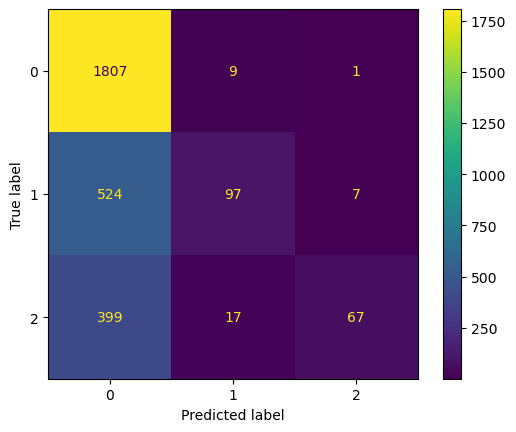

In [27]:
report(nb)

LogisticRegression(max_iter=10000) model
              precision    recall  f1-score   support

    negative       0.80      0.93      0.86      1817
     neutral       0.63      0.47      0.54       628
    positive       0.82      0.58      0.68       483

    accuracy                           0.77      2928
   macro avg       0.75      0.66      0.69      2928
weighted avg       0.77      0.77      0.76      2928



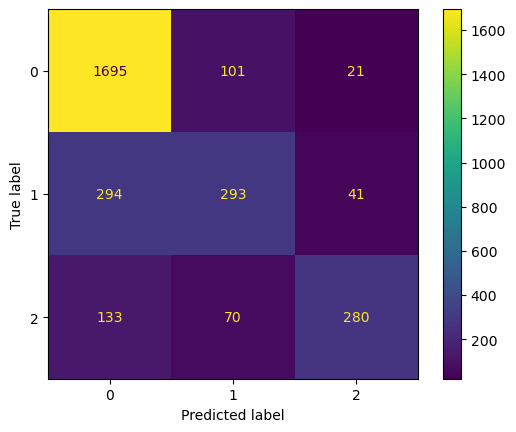

In [28]:
report(log)

RandomForestClassifier() model
              precision    recall  f1-score   support

    negative       0.77      0.93      0.84      1817
     neutral       0.59      0.35      0.44       628
    positive       0.72      0.52      0.61       483

    accuracy                           0.74      2928
   macro avg       0.69      0.60      0.63      2928
weighted avg       0.72      0.74      0.72      2928



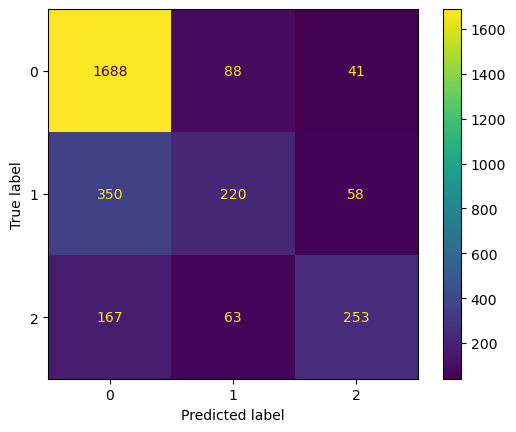

In [29]:
report(rfc)

###### PipeLine for deployment on New Tweets

In [30]:
from sklearn.pipeline import Pipeline

In [52]:
pipe = Pipeline([('tfidf',TfidfVectorizer()),('nb',MultinomialNB())])

In [53]:
pipe.fit(X,y)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('nb', MultinomialNB())])

In [54]:
new_tweet = ['bad flight']
pipe.predict(new_tweet)

array(['negative'], dtype='<U8')

In [55]:
new_tweet = ['I would love to travel again with your airline. Best in the world','Horrible experience']
pipe.predict(new_tweet)

array(['negative', 'negative'], dtype='<U8')

In [56]:
new_tweet = ["My father, a senior citizen, bought Zero Cancellation from  @IndiGo6E (PNR N17WXY). Despite that IndiGo Airlines is charging him cancellation fee when he wants to cancel. Feels like cheating unsuspecting passengers, esp. seniors. Please resolve & refund. #CustomerRights "]

In [57]:
pipe.predict(new_tweet)

array(['negative'], dtype='<U8')

In [58]:
new_tweet =[" I Like facilities here. Clean and Mostly affordable  I like the seats. A proper airline. "]
pipe.predict(new_tweet)

array(['negative'], dtype='<U8')